# Data-Driven Research in Digital Humanities
## Television News Archive — COVID-19 Coverage Analysis

---

### How to use this notebook

You do not need to understand every line of code. Each cell has comments (lines starting with `#`) that explain what the code is doing in plain language. Focus on the **questions** each cell asks and on the **graphs** it produces. Run cells in order by pressing **Shift + Enter**.

---

### Data provenance

**Before we touch any data, we document where it comes from.** This is good practice — for yourself and for anyone who reads your work.

**Television coverage data**  
Source: [GDELT Television Explorer](https://api.gdeltproject.org/api/v2/summary/summary?d=iatv&t=summary)  
Underlying archive: [Internet Archive Television News Archive](https://archive.org/details/tv)  
What the numbers mean: percentage of monitored airtime (counted in 15-second intervals) in which the keyword appeared in the closed captions  
Stations: Al Jazeera (ALJAZ), BBC News (BBCNEWS), Bloomberg (BLOOMBERG), CNN (CNN), C-SPAN (CSPAN), Deutsche Welle (DW), Fox News (FOXNEWS), RT (RT)  
Period: December 2019 – October 2024 | Downloaded: June 2026  

**Epidemiological data**  
Source: [Our World in Data — COVID-19 deaths per million](https://ourworldindata.org/covid-deaths)  
Original source: WHO / Johns Hopkins University | Geography: United States only  

**Declared limits**  
- Closed captions are typed by human stenographers watching live. They work under time pressure: technical terms get misspelled, proper names get dropped. A zero in the data does not mean the topic was not discussed.  
- The keyword you search determines what you find. Searching for 'coronavirus' will miss every segment where the captioner typed 'covid' instead.  
- This archive covers primarily American and British national television — not global media.  
- The deaths data covers the United States only.  

> *As [Henrich, Heine and Norenzayan argued in 2010](https://doi.org/10.1038/466029a): most people are not WEIRD (Western, Educated, Industrialised, Rich, Democratic). Neither are most media systems. Keep that in mind before generalising from this archive.*


---
### Setup — loading the data

There are three ways to load the data files into this notebook. Choose the one that works best for you.

| Option | When to use |
|---|---|
| **Option A — Google Drive** | You want to keep the files and reuse them across sessions |
| **Option B — Upload directly** | Quick one-off use, no Drive setup needed |
| **Option C — Download from GitHub** | Fastest if you have internet — no upload needed |

Run **only one** of the three setup cells below, then continue with the libraries cell.


In [ ]:
# ── OPTION A — Google Drive ─────────────────────────────────────────────────
# ── WHERE YOUR DATA NEEDS TO BE ─────────────────────────────────────────────
# This notebook reads data files from your Google Drive.
# Before running this cell, make sure you have:
#   1. A folder called 'UvA_demo' inside 'My Drive' on Google Drive
#   2. All the CSV data files from the course repository copied into that folder
#
# The folder path should look like this:
#   My Drive/
#   └── UvA_demo/
#       ├── results-corona.csv
#       ├── results-covid.csv
#       ├── results-coronaOrCovid.csv
#       └── daily-new-confirmed-covid-19-deaths-per-million-people.csv
#
# ── STEP 1: CONNECT TO GOOGLE DRIVE ─────────────────────────────────────────
# This will open a popup asking you to sign in with your Google account.
# Once connected, your Drive will be accessible from this notebook.
from google.colab import drive
drive.mount('/content/drive')

import os

# ── STEP 2: NAVIGATE TO THE DATA FOLDER ─────────────────────────────────────
# This tells Python to look for files in your UvA_demo folder.
# If you named your folder differently, change 'UvA_demo' below.
os.chdir('/content/drive/MyDrive/UvA_demo')

# ── STEP 3: CHECK ALL FILES ARE PRESENT ─────────────────────────────────────
# If any file shows '✗ MISSING', go to your Drive and check the folder.
required_files = [
    'results-corona.csv',
    'results-covid.csv',
    'results-coronaOrCovid.csv',
    'daily-new-confirmed-covid-19-deaths-per-million-people.csv',
]
print('Checking files...')
for f in required_files:
    status = '✓ found' if os.path.exists(f) else '✗ MISSING — check your UvA_demo folder on Google Drive'
    print(f'  {status}: {f}')


In [ ]:
# ── OPTION B — Upload files directly ────────────────────────────────────────
# A file picker will open. Select all four CSV files at once.
# Note: you will need to re-upload every time the Colab session restarts.
from google.colab import files
uploaded = files.upload()
print('Files uploaded:', list(uploaded.keys()))


In [1]:
# ── OPTION C — Download from GitHub ─────────────────────────────────────────
# This downloads the data files directly from the course repository.
# No Drive setup or file upload needed — just run this cell.
# Replace YOUR_USERNAME and YOUR_REPO with the actual GitHub repository path.
import subprocess

base_url = 'https://raw.githubusercontent.com/LuciaGiagnolini12/DataDrivenResearch_TrialClassUvA/main/data/'

data_files = [
    'results-corona.csv',
    'results-covid.csv',
    'results-coronaOrCovid.csv',
    'daily-new-confirmed-covid-19-deaths-per-million-people.csv',
]

print('Downloading files...')
for f in data_files:
    result = subprocess.run(['wget', '-q', base_url + f], capture_output=True)
    status = '✓' if result.returncode == 0 else '✗ failed'
    print(f'  {status}: {f}')
print('Done.')


  ✓: results-corona.csv
  ✓: results-covid.csv
  ✓: results-coronaOrCovid.csv
  ✓: daily-new-confirmed-covid-19-deaths-per-million-people.csv
Done.


In [7]:
# Load the libraries we need
# pandas: works with tabular data (like a spreadsheet, but in code)
# matplotlib: draws graphs
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Define a colour for each TV station
# Using a dictionary so we can look up the colour by station name
COLORS = {
    'CNN':     '#CC0000',  # red
    'FOXNEWS': '#003399',  # blue
    'BBCNEWS': '#FF6600',  # orange
    'RT':      '#8B0000',  # dark red
    'ALJAZ':   '#0099CC',  # light blue
    'DW':      '#336633',  # dark green
}

def load_gdelt(filepath, value_col='value'):
    """
    Load a CSV file exported from the GDELT Television Explorer.
    These files always have three columns: date, station name, value.
    We rename them to consistent names and convert the date to a proper format.
    """
    df = pd.read_csv(filepath)
    df.columns = ['date', 'station', value_col]
    # The date comes as '1/2020' — we convert it to a proper date object
    df['date'] = pd.to_datetime(df['date'], format='%m/%Y')
    return df

print('Libraries loaded. Ready to go.')


Libraries loaded. Ready to go.


---
## Searching for 'coronavirus'

We start with the most obvious keyword and reproduce the graph you just saw in the GDELT browser. This is the same data — but now you can see exactly what the code is doing, and you can modify it.


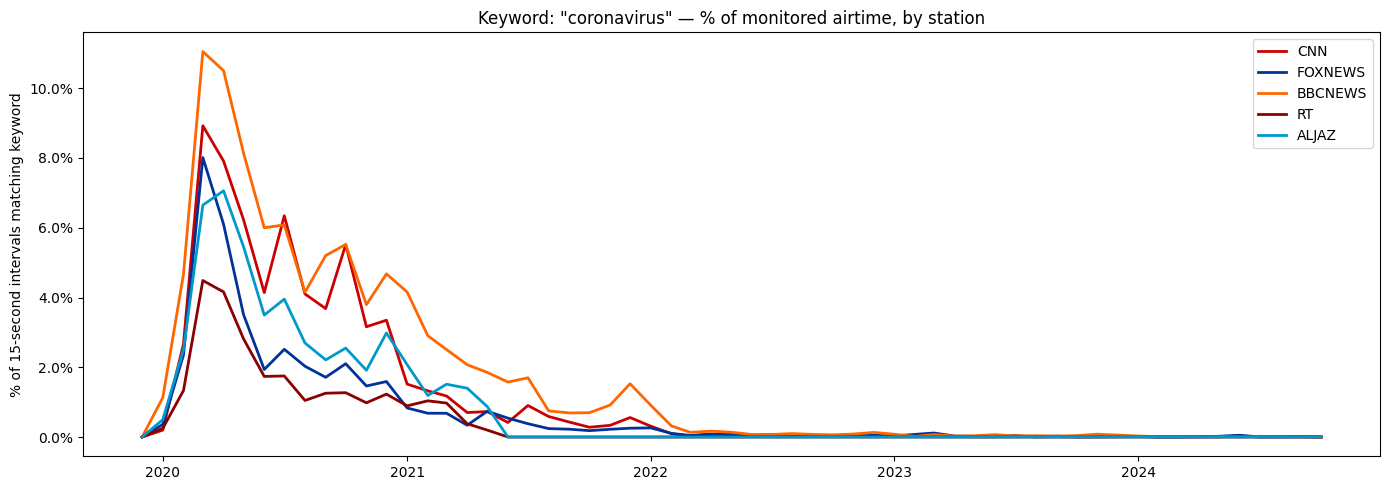

The curve peaks in March 2020 and drops sharply from mid-2021.
Question: does this mean coverage of the pandemic declined — or does it mean something else?


In [9]:
# Load the data for the keyword 'coronavirus'
# Each row in this file = one month, one station, one percentage value
corona = load_gdelt('results-corona.csv')

# Select the stations we want to compare
# Note: MSNBC is not in this dataset — it was not included in this GDELT export
stations = ['CNN', 'FOXNEWS', 'BBCNEWS', 'RT', 'ALJAZ']
df = corona[corona['station'].isin(stations)]

# Draw the graph
# For each station, we select its rows, sort by date, and draw a line
fig, ax = plt.subplots(figsize=(14, 5))
for s in stations:
    d = df[df['station'] == s].sort_values('date')
    ax.plot(d['date'], d['value'], label=s, color=COLORS[s], linewidth=2)

ax.set_title('Keyword: "coronavirus" — % of monitored airtime, by station')
ax.set_ylabel('% of 15-second intervals matching keyword')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend()
plt.tight_layout()
plt.show()

print('The curve peaks in March 2020 and drops sharply from mid-2021.')
print('Question: does this mean coverage of the pandemic declined — or does it mean something else?')

---
## 'coronavirus' vs 'covid' vs 'covid': a terminology shift

Is 'coronavirus' sufficient to map how media covered the pandemic? We could search for all the terms used — coronavirus, covid, covid-19. Let us start with 'covid'.

> **Operationalisation**: the keyword you search is not the same as the concept you are studying. 'Coronavirus' in a caption is a count of how often captioners typed that specific word — not a measure of editorial attention to the pandemic. The two are related, but they are not identical.


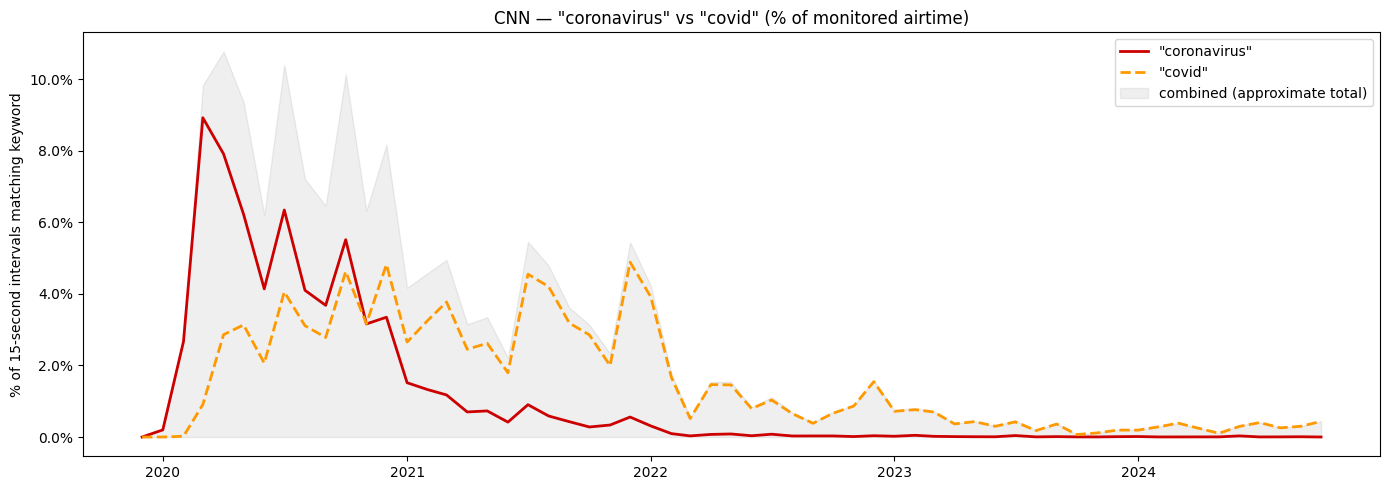

'covid' overtakes 'coronavirus' on CNN from: November 2020

The keyword disappeared. The coverage did not.
A researcher searching only for "coronavirus" would undercount COVID coverage from late 2020 onwards.


In [4]:
# Load the data for the keyword 'covid'
covid_df = load_gdelt('results-covid.csv')

# We focus on CNN to keep the graph readable
# .rename() gives the 'value' column a more descriptive name so we can tell the two apart
cnn_corona = (corona[corona['station'] == 'CNN']
              .sort_values('date')
              .rename(columns={'value': 'coronavirus'}))

cnn_covid = (covid_df[covid_df['station'] == 'CNN']
             .sort_values('date')
             .rename(columns={'value': 'covid'}))

# Merge the two datasets on the date column
# This gives us one row per month with both values side by side
merged = pd.merge(
    cnn_corona[['date', 'coronavirus']],
    cnn_covid[['date', 'covid']],
    on='date'
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['date'], merged['coronavirus'],
        color='#CC0000', linewidth=2, label='"coronavirus"')
ax.plot(merged['date'], merged['covid'],
        color='#FF9900', linewidth=2, linestyle='--', label='"covid"')

# The shaded area shows the approximate combined coverage
ax.fill_between(merged['date'],
                merged['coronavirus'] + merged['covid'],
                alpha=0.08, color='#333333',
                label='combined (approximate total)')

ax.set_title('CNN — "coronavirus" vs "covid" (% of monitored airtime)')
ax.set_ylabel('% of 15-second intervals matching keyword')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend()
plt.tight_layout()
plt.show()

# Find the first month when 'covid' overtakes 'coronavirus'
crossover = merged[merged['covid'] > merged['coronavirus']].head(1)
if not crossover.empty:
    month = crossover['date'].dt.strftime('%B %Y').values[0]
    print(f"'covid' overtakes 'coronavirus' on CNN from: {month}")
print()
print('The keyword disappeared. The coverage did not.')
print('A researcher searching only for "coronavirus" would undercount COVID coverage from late 2020 onwards.')


---
## Total coverage vs. actual deaths

But we can push further. We combine both keywords and bring in a second dataset from a completely different source: daily COVID death counts per million people from Our World in Data. Different institution, different methodology, different object of measurement — but the same time period.

> **Note**: we are putting two different types of measurement on the same graph: editorial attention (% airtime) on the left axis, and epidemiological severity (deaths per million) on the right. They are not the same thing. The question is not whether they match — it is *where and why they diverge*.


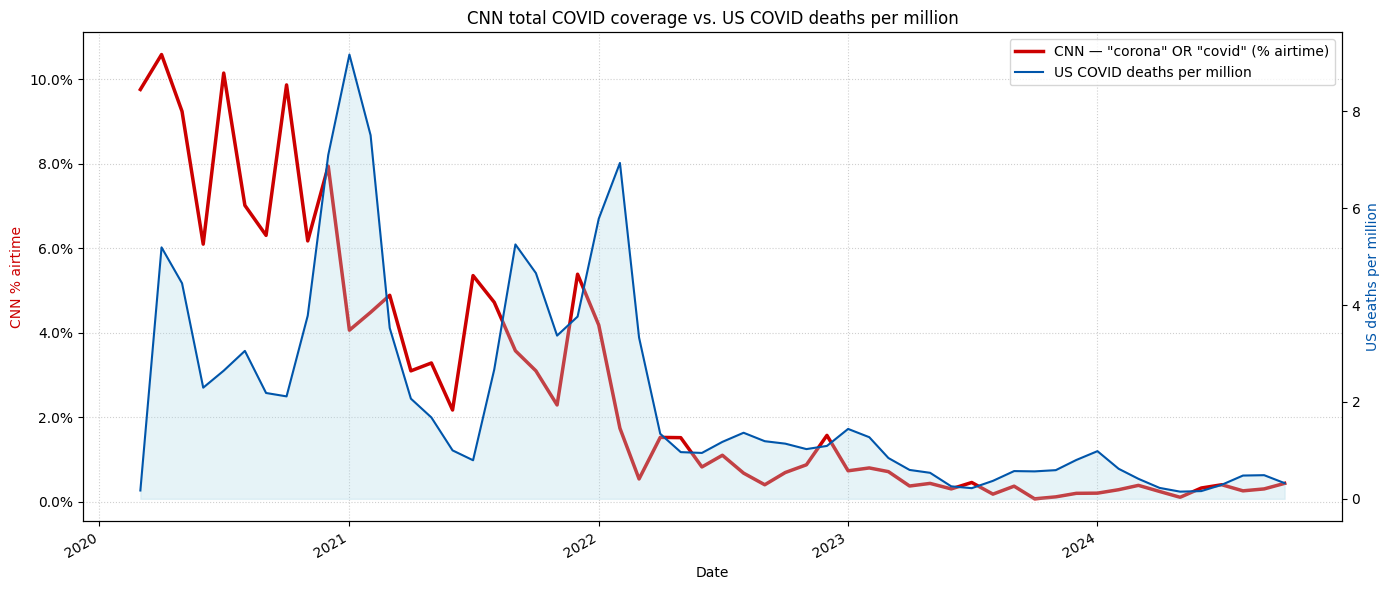

Peak CNN coverage: April 2020 (10.6% airtime)
Peak US deaths:    January 2021 (9.2 per million)

The deadliest wave does not receive the same level of coverage.
Is this audience fatigue? An editorial decision? A political context?
The data gives you the pattern. History, context, and argument give you the interpretation.


In [5]:
# Load the combined 'corona OR covid' dataset — the most complete picture of coverage
coronaOrCovid = load_gdelt('results-coronaOrCovid.csv')

# Load the epidemiological data (daily US COVID deaths per million people)
deaths = pd.read_csv('daily-new-confirmed-covid-19-deaths-per-million-people.csv')
deaths.columns = ['entity', 'code', 'date', 'deaths_per_million']
deaths['date'] = pd.to_datetime(deaths['date'])

# The deaths data is daily; we resample it to monthly averages
# so it matches the monthly TV coverage data
# 'MS' means Month Start — each monthly value is assigned to the first day of the month
deaths_monthly = (deaths
                  .set_index('date')['deaths_per_million']
                  .resample('MS')
                  .mean()
                  .reset_index())
deaths_monthly.columns = ['date', 'deaths_per_million']

# Get CNN's combined coverage and merge with deaths data
# how='inner' keeps only months that appear in both datasets
cnn = coronaOrCovid[coronaOrCovid['station'] == 'CNN'].sort_values('date')
merged2 = pd.merge(cnn, deaths_monthly, on='date', how='inner')

# This graph has two Y axes — one for each variable
# twinx() creates a second axis sharing the same X axis
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Left axis: CNN coverage (red line)
ax1.plot(merged2['date'], merged2['value'],
         color='#CC0000', linewidth=2.5,
         label='CNN — "corona" OR "covid" (% airtime)')

# Right axis: deaths (blue shaded area + line)
ax2.fill_between(merged2['date'], merged2['deaths_per_million'],
                 alpha=0.3, color='#ADD8E6')
ax2.plot(merged2['date'], merged2['deaths_per_million'],
         color='#0055AA', linewidth=1.5,
         label='US COVID deaths per million')

ax1.set_ylabel('CNN % airtime', color='#CC0000')
ax2.set_ylabel('US deaths per million', color='#0055AA')
ax1.set_title('CNN total COVID coverage vs. US COVID deaths per million')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.set_xlabel('Date')
ax1.grid(True, linestyle=':', alpha=0.6)
fig.autofmt_xdate()

# Combine the legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

# Print the key finding directly
peak_coverage = merged2.loc[merged2['value'].idxmax()]
peak_deaths = merged2.loc[merged2['deaths_per_million'].idxmax()]
print(f"Peak CNN coverage: {peak_coverage['date'].strftime('%B %Y')} ({peak_coverage['value']:.1f}% airtime)")
print(f"Peak US deaths:    {peak_deaths['date'].strftime('%B %Y')} ({peak_deaths['deaths_per_million']:.1f} per million)")
print()
print('The deadliest wave does not receive the same level of coverage.')
print('Is this audience fatigue? An editorial decision? A political context?')
print('The data gives you the pattern. History, context, and argument give you the interpretation.')
